Select 'bank-full.csv' from your computer:


Saving bank-full.csv to bank-full (1).csv


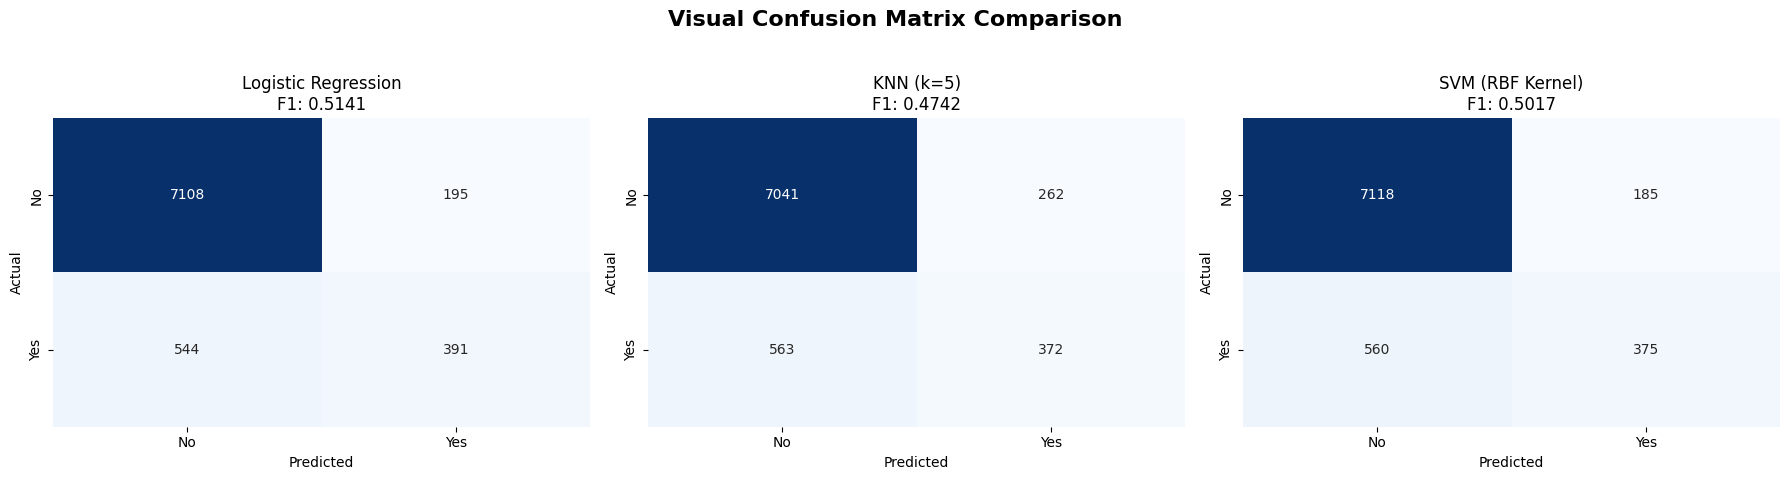


FINAL COMPARISON SUMMARY
Logistic Regression  | F1-Score: 0.5141
KNN (k=5)            | F1-Score: 0.4742
SVM (RBF Kernel)     | F1-Score: 0.5017


In [3]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score

# --- 1. DATA UPLOAD ---
print("Select 'bank-full.csv' from your computer:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';')

# --- 2. PREPROCESSING ---
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. MODEL TRAINING & PREDICTION ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF Kernel)": SVC(kernel='rbf')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = {
        "f1": f1_score(y_test, preds),
        "cm": confusion_matrix(y_test, preds)
    }

# --- 4. VISUALIZATION (THE "IMAGE FORM") ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Visual Confusion Matrix Comparison', fontsize=16, fontweight='bold')

for i, (name, data) in enumerate(results.items()):
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cbar=False)
    axes[i].set_title(f"{name}\nF1: {data['f1']:.4f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 5. PRINT SUMMARY TABLE ---
print("\n" + "="*30)
print("FINAL COMPARISON SUMMARY")
print("="*30)
for name, data in results.items():
    print(f"{name:20} | F1-Score: {data['f1']:.4f}")